# Modelo com Rebalanceamento e Custos de Transação 

In [1]:
import pandas as pd
import numpy as np
import random
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.environ import SolverFactory
import yfinance as yf
from pathlib import Path
import os
import matplotlib.pyplot as plt


In [2]:
lista_macro = []

for filename in os.listdir(path='../../base_dados/brapi/macro'):
    
    # 2. Reconstruct the full absolute or relative path to the file
    full_path = os.path.join('../../base_dados/brapi/macro/',filename)
    
    # 3. Check if the current item is actually a file (and not a subfolder)
    # if os.path.isfile(full_path):
        
    #     # 4. Open and process the file safely
    #     with open(full_path, "r", encoding="utf-8") as file:
    #         content = file.read()
    #         print(f"--- Content of {filename} ---")
    #         print(pd.read_csv(full_path))
    dicio = {
        'macro':filename,
        'data':pd.read_csv(full_path)
    }

    lista_macro.append(dicio)

In [3]:
lista_macro[0]['data'].set_index('date', inplace=True)

In [4]:
lista_macro[0]['data'].describe().loc['std']['valor_anual']

np.float64(4.231617229847328)

In [5]:
selic_d = lista_macro[0]['data']

In [6]:
basedados_ativos = Path('../../base_dados/retornos_ativos_2015_2026.csv') 
basedados_ibov = Path('../../base_dados/retorno_ibov_2015_2026.csv') 

lista_magic_formula = []

for filename in os.listdir(path='../../base_dados/brapi/magic_formula/'):
    
    # 2. Reconstruct the full absolute or relative path to the file
    full_path = os.path.join('../../base_dados/brapi/magic_formula/', filename)
    
    # 3. Check if the current item is actually a file (and not a subfolder)
    # if os.path.isfile(full_path):
        
    #     # 4. Open and process the file safely
    #     with open(full_path, "r", encoding="utf-8") as file:
    #         content = file.read()
    #         print(f"--- Content of {filename} ---")
    #         print(pd.read_csv(full_path))
    dicio = {
        'ativo':filename,
        'data':pd.read_csv(full_path)
    }

    lista_magic_formula.append(dicio)

df_ativos=pd.read_csv(basedados_ativos).set_index(['Date']).fillna(0)

df_ibov=pd.read_csv(basedados_ibov).set_index(['Date']).fillna(0)



In [7]:
lista_ativos=[]
for ativo in df_ativos.columns.tolist():
    lista_ativos.append(ativo.replace('.SA',''))
    df_ativos.rename(columns={ativo:ativo.replace('.SA','')},inplace=True)

In [8]:
df_ativos.shape[0]

2857

In [9]:
print(f'tamanho mf original: ',len(lista_magic_formula))
lista_mf_check = []
lista_ativos_finais = []
for i in range(len(lista_magic_formula)):
    if lista_magic_formula[i]['ativo'] in lista_ativos:
        lista_ativos_finais.append(lista_magic_formula[i]['ativo'])
        dc = {
            'ativo':lista_magic_formula[i]['ativo'],
            'data':lista_magic_formula[i]['data']
        }
        lista_mf_check.append(dc)
    else:
        print(f"Nao está na lista: {lista_magic_formula[i]['ativo']}")
print(f'tamanho mf Final: ',len(lista_mf_check))
        

tamanho mf original:  69
tamanho mf Final:  69


In [10]:
lista_mf_check

[{'ativo': 'ABEV3',
  'data':     Unnamed: 0     endDate       ROC        EY
  0            0  2025-12-31  0.903659  0.111531
  1            1  2024-12-31  0.624135  0.141094
  2            2  2023-12-31  0.840339  0.101218
  3            3  2022-12-31  0.646090  0.093623
  4            4  2021-12-31  0.585286  0.089962
  5            5  2020-12-31  0.598088  0.085787
  6            6  2019-12-31  0.637351  0.073615
  7            7  2018-12-31  0.824850  0.092799
  8            8  2017-12-31  1.105830  0.069359
  9            9  2016-12-31  1.198593  0.096538
  10          10  2015-12-31  1.084847  0.104877
  11          11  2014-12-31  1.081966  0.102054
  12          12  2013-12-31  0.892491  0.099119
  13          13  2012-12-31  0.762046  0.000204},
 {'ativo': 'ALOS3',
  'data':     Unnamed: 0     endDate       ROC        EY
  0            0  2025-12-31  0.719754  0.069923
  1            1  2024-12-31  0.690710  0.089326
  2            2  2023-12-31  3.051214  0.259800
  3        

In [11]:
df_ativos = df_ativos.filter(lista_ativos_finais)

In [12]:
#ativos
df_ativos_2016 = df_ativos[df_ativos.index.str.startswith('2016')]
df_ativos_2017 = df_ativos[df_ativos.index.str.startswith('2017')]
df_ativos_2018 = df_ativos[df_ativos.index.str.startswith('2018')]
df_ativos_2019 = df_ativos[df_ativos.index.str.startswith('2019')]
df_ativos_2020 = df_ativos[df_ativos.index.str.startswith('2020')]
df_ativos_2021 = df_ativos[df_ativos.index.str.startswith('2021')]
df_ativos_2022 = df_ativos[df_ativos.index.str.startswith('2022')]
df_ativos_2023 = df_ativos[df_ativos.index.str.startswith('2023')]
df_ativos_2024 = df_ativos[df_ativos.index.str.startswith('2024')]
df_ativos_2025 = df_ativos[df_ativos.index.str.startswith('2025')]
df_ativos_2026 = df_ativos[df_ativos.index.str.startswith('2026')]

#ibov
df_ibov_2016 = df_ibov[df_ibov.index.str.startswith('2016')]
df_ibov_2017 = df_ibov[df_ibov.index.str.startswith('2017')]
df_ibov_2018 = df_ibov[df_ibov.index.str.startswith('2018')]
df_ibov_2019 = df_ibov[df_ibov.index.str.startswith('2019')]
df_ibov_2020 = df_ibov[df_ibov.index.str.startswith('2020')]
df_ibov_2021 = df_ibov[df_ibov.index.str.startswith('2021')]
df_ibov_2022 = df_ibov[df_ibov.index.str.startswith('2022')]
df_ibov_2023 = df_ibov[df_ibov.index.str.startswith('2023')]
df_ibov_2024 = df_ibov[df_ibov.index.str.startswith('2024')]
df_ibov_2025 = df_ibov[df_ibov.index.str.startswith('2025')]
df_ibov_2026 = df_ibov[df_ibov.index.str.startswith('2026')]

In [13]:
selic_d_2016 = selic_d[selic_d.index.isin(df_ativos_2016.index)]
selic_d_2016['valor_diario'] = selic_d_2016['valor_diario']/100

In [14]:
df_ativos_2016

,ABEV3,ALOS3,AXIA3,AZZA3,B3SA3,BBAS3,BBDC3,BBDC4,BBSE3,BEEF3,...,SUZB3,TAEE11,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3,YDUQ3
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,-0.035854,0.001236,-0.057292,-0.059524,-0.040404,-0.033922,-0.014634,-0.014523,-0.061652,-0.060150,...,0.0,-0.035821,-0.010957,-0.048801,-0.058064,-0.026094,0.0,-0.102649,-0.020736,-0.003584
2016-01-05,0.015689,0.000000,0.022100,0.007089,0.038277,0.003511,0.007792,0.003634,0.063951,0.035200,...,0.0,-0.015480,-0.004887,0.022956,-0.082192,-0.013396,0.0,0.001647,0.048498,-0.103597
2016-01-06,-0.009725,0.000617,-0.018018,-0.014580,-0.000922,0.000000,-0.017700,-0.014173,-0.007822,-0.014683,...,0.0,0.003145,0.024886,-0.007140,-0.089552,-0.073483,0.0,0.001645,-0.022802,0.085072
2016-01-07,-0.026574,-0.000617,-0.049541,0.031123,-0.041513,-0.023793,-0.032032,-0.020234,-0.039419,-0.050196,...,0.0,-0.033229,-0.026198,-0.040240,-0.057377,-0.059483,0.0,-0.000328,-0.028666,-0.005178
2016-01-08,0.013057,0.004938,-0.027027,0.013854,0.012512,0.000000,-0.002068,-0.019566,0.019006,-0.013212,...,0.0,0.042802,0.002296,0.016057,0.026087,-0.033914,0.0,-0.047963,-0.004805,-0.059479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-23,0.011378,0.007647,0.015454,0.002057,0.028758,0.028462,0.023971,0.020935,0.005535,0.001688,...,0.0,-0.007264,0.000419,-0.001212,-0.002525,-0.007486,0.0,0.012324,0.026971,0.041892
2016-12-26,0.011250,0.015761,0.020591,-0.014374,0.008895,0.015707,0.020483,0.018309,0.002936,0.007582,...,0.0,-0.015610,0.002094,0.001517,0.012658,0.031759,0.0,0.007928,-0.008754,0.000000
2016-12-27,-0.004326,-0.010345,-0.017106,-0.000417,0.013854,0.006995,0.002509,-0.009709,-0.015368,0.010869,...,0.0,0.005946,0.001671,0.005455,0.025000,-0.005002,0.0,-0.001405,0.016305,-0.004539


In [15]:
exc_2016 = df_ativos_2016.sub(selic_d_2016['valor_diario'], axis=0)
sharpe_2016 = exc_2016.mean() / df_ativos_2016.std()   # Series: index=ticker


In [16]:
exc_2016.mean()

ABEV3   -0.000213
ALOS3    0.000460
AXIA3    0.005981
AZZA3    0.001005
B3SA3    0.001950
           ...   
VALE3    0.003541
VBBR3   -0.000109
VIVT3    0.000613
WEGE3    0.000350
YDUQ3    0.001443
Length: 69, dtype: float64

In [17]:
exc_2016.var()

ABEV3    1.857643e-04
ALOS3    4.203277e-04
AXIA3    1.117532e-03
AZZA3    5.470285e-04
B3SA3    5.343569e-04
             ...     
VALE3    1.803142e-03
VBBR3    1.658036e-13
VIVT3    5.092660e-04
WEGE3    4.237409e-04
YDUQ3    1.158904e-03
Length: 69, dtype: float64

In [18]:
sigma_2016 = exc_2016.cov()

In [19]:
sigma_2016

,ABEV3,ALOS3,AXIA3,AZZA3,B3SA3,BBAS3,BBDC3,BBDC4,BBSE3,BEEF3,...,SUZB3,TAEE11,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3,YDUQ3
ABEV3,1.857643e-04,3.882087e-05,1.412656e-04,8.976009e-05,1.298149e-04,1.648507e-04,1.258232e-04,1.299559e-04,1.516443e-04,3.599310e-05,...,3.078583e-07,6.104436e-05,1.038451e-04,1.093155e-04,8.645480e-05,1.929648e-04,-4.704233e-10,1.160840e-04,1.314712e-04,1.062520e-04
ALOS3,3.882087e-05,4.203277e-04,8.438046e-05,7.855790e-05,1.483019e-04,1.900653e-04,1.316133e-04,1.489770e-04,9.228425e-05,2.769014e-05,...,1.994943e-07,7.885630e-05,2.675717e-05,5.622593e-05,3.034654e-04,1.933133e-04,-5.571289e-10,5.282595e-05,6.038165e-05,8.894494e-05
AXIA3,1.412656e-04,8.438046e-05,1.117532e-03,1.547592e-04,3.265377e-04,5.079805e-04,3.436896e-04,4.179240e-04,3.421668e-04,1.423937e-04,...,-1.126173e-06,9.850124e-05,6.970688e-05,1.592786e-04,7.106890e-04,3.316526e-04,-1.332651e-09,2.015026e-04,2.093848e-04,2.033234e-04
AZZA3,8.976009e-05,7.855790e-05,1.547592e-04,5.470285e-04,1.948095e-04,2.671184e-04,1.829095e-04,2.436315e-04,1.736969e-04,6.234764e-06,...,4.430864e-07,9.388363e-05,1.009045e-04,8.778039e-05,3.419979e-04,2.174849e-04,-8.820832e-10,8.229385e-05,1.257443e-04,1.495670e-04
B3SA3,1.298149e-04,1.483019e-04,3.265377e-04,1.948095e-04,5.343569e-04,5.014044e-04,3.441961e-04,3.823077e-04,3.505617e-04,9.422759e-05,...,4.881455e-08,1.091902e-04,1.496593e-04,1.457659e-04,6.183703e-04,3.676249e-04,-5.476973e-10,1.560851e-04,1.687425e-04,2.014350e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VALE3,1.929648e-04,1.933133e-04,3.316526e-04,2.174849e-04,3.676249e-04,5.378647e-04,3.631534e-04,4.718450e-04,3.100813e-04,2.227360e-04,...,1.645120e-06,1.128312e-04,1.845552e-04,1.690502e-04,1.218829e-03,1.803142e-03,6.797242e-11,2.982101e-04,2.220364e-04,4.206536e-04
VBBR3,-4.704233e-10,-5.571289e-10,-1.332651e-09,-8.820832e-10,-5.476973e-10,-5.129639e-10,-4.919491e-10,-7.214415e-10,-5.321234e-10,5.074780e-10,...,-9.700632e-12,7.952272e-11,-5.677994e-11,-2.927280e-10,-6.806679e-10,6.797242e-11,1.658036e-13,-1.211433e-10,-3.912379e-10,-6.866906e-10
VIVT3,1.160840e-04,5.282595e-05,2.015026e-04,8.229385e-05,1.560851e-04,3.176651e-04,1.921130e-04,1.992927e-04,2.073140e-04,1.012943e-04,...,1.145224e-06,1.416386e-04,8.894928e-05,1.410551e-04,3.351043e-04,2.982101e-04,-1.211433e-10,5.092660e-04,1.605200e-04,1.888615e-04
WEGE3,1.314712e-04,6.038165e-05,2.093848e-04,1.257443e-04,1.687425e-04,2.890841e-04,2.071932e-04,2.372811e-04,2.213850e-04,5.253340e-05,...,1.545415e-06,9.461188e-05,1.443303e-04,1.426024e-04,1.855514e-04,2.220364e-04,-3.912379e-10,1.605200e-04,4.237409e-04,1.517862e-04


In [20]:
exc_2016.cov()

,ABEV3,ALOS3,AXIA3,AZZA3,B3SA3,BBAS3,BBDC3,BBDC4,BBSE3,BEEF3,...,SUZB3,TAEE11,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3,YDUQ3
ABEV3,1.857643e-04,3.882087e-05,1.412656e-04,8.976009e-05,1.298149e-04,1.648507e-04,1.258232e-04,1.299559e-04,1.516443e-04,3.599310e-05,...,3.078583e-07,6.104436e-05,1.038451e-04,1.093155e-04,8.645480e-05,1.929648e-04,-4.704233e-10,1.160840e-04,1.314712e-04,1.062520e-04
ALOS3,3.882087e-05,4.203277e-04,8.438046e-05,7.855790e-05,1.483019e-04,1.900653e-04,1.316133e-04,1.489770e-04,9.228425e-05,2.769014e-05,...,1.994943e-07,7.885630e-05,2.675717e-05,5.622593e-05,3.034654e-04,1.933133e-04,-5.571289e-10,5.282595e-05,6.038165e-05,8.894494e-05
AXIA3,1.412656e-04,8.438046e-05,1.117532e-03,1.547592e-04,3.265377e-04,5.079805e-04,3.436896e-04,4.179240e-04,3.421668e-04,1.423937e-04,...,-1.126173e-06,9.850124e-05,6.970688e-05,1.592786e-04,7.106890e-04,3.316526e-04,-1.332651e-09,2.015026e-04,2.093848e-04,2.033234e-04
AZZA3,8.976009e-05,7.855790e-05,1.547592e-04,5.470285e-04,1.948095e-04,2.671184e-04,1.829095e-04,2.436315e-04,1.736969e-04,6.234764e-06,...,4.430864e-07,9.388363e-05,1.009045e-04,8.778039e-05,3.419979e-04,2.174849e-04,-8.820832e-10,8.229385e-05,1.257443e-04,1.495670e-04
B3SA3,1.298149e-04,1.483019e-04,3.265377e-04,1.948095e-04,5.343569e-04,5.014044e-04,3.441961e-04,3.823077e-04,3.505617e-04,9.422759e-05,...,4.881455e-08,1.091902e-04,1.496593e-04,1.457659e-04,6.183703e-04,3.676249e-04,-5.476973e-10,1.560851e-04,1.687425e-04,2.014350e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VALE3,1.929648e-04,1.933133e-04,3.316526e-04,2.174849e-04,3.676249e-04,5.378647e-04,3.631534e-04,4.718450e-04,3.100813e-04,2.227360e-04,...,1.645120e-06,1.128312e-04,1.845552e-04,1.690502e-04,1.218829e-03,1.803142e-03,6.797242e-11,2.982101e-04,2.220364e-04,4.206536e-04
VBBR3,-4.704233e-10,-5.571289e-10,-1.332651e-09,-8.820832e-10,-5.476973e-10,-5.129639e-10,-4.919491e-10,-7.214415e-10,-5.321234e-10,5.074780e-10,...,-9.700632e-12,7.952272e-11,-5.677994e-11,-2.927280e-10,-6.806679e-10,6.797242e-11,1.658036e-13,-1.211433e-10,-3.912379e-10,-6.866906e-10
VIVT3,1.160840e-04,5.282595e-05,2.015026e-04,8.229385e-05,1.560851e-04,3.176651e-04,1.921130e-04,1.992927e-04,2.073140e-04,1.012943e-04,...,1.145224e-06,1.416386e-04,8.894928e-05,1.410551e-04,3.351043e-04,2.982101e-04,-1.211433e-10,5.092660e-04,1.605200e-04,1.888615e-04
WEGE3,1.314712e-04,6.038165e-05,2.093848e-04,1.257443e-04,1.687425e-04,2.890841e-04,2.071932e-04,2.372811e-04,2.213850e-04,5.253340e-05,...,1.545415e-06,9.461188e-05,1.443303e-04,1.426024e-04,1.855514e-04,2.220364e-04,-3.912379e-10,1.605200e-04,4.237409e-04,1.517862e-04


#### Dados da Magic Formula

In [21]:
lista_scores_ativos = []
i=0
anos = ['2025-12-31',
 '2024-12-31',
 '2023-12-31',
 '2022-12-31',
 '2021-12-31',
 '2020-12-31',
 '2019-12-31',
 '2018-12-31',
 '2017-12-31',
 '2016-12-31',
 '2015-12-31',
 ]

ano_escolhido = ['2015-12-31']

dict_score = {}

for i, ativo in enumerate(df_ativos_2016.columns.tolist()):
    if ativo == lista_mf_check[i]['ativo']:
        for ano in ano_escolhido:
            df_temp = lista_mf_check[i]['data'].query("endDate in @ano")
            score_anual = (0.5*df_temp['ROC'] + 0.5*df_temp['EY']).sum()
            dict_score[(ano, ativo)] = score_anual

    else:
        print(f" ativo: {ativo}")
        print(f" ativo_mf: {lista_mf_check[i]['ativo']}")
df_scores = pd.Series(dict_score).unstack()  # index=anos, columns=ativos
df_scores = df_scores.replace([np.inf, -np.inf],0)


In [22]:
# df_score_normalized = (df_scores.T - df_scores.T.mean()) / (df_scores.T.max() - df_scores.T.min())

In [23]:
scores_rank = df_scores.rank(axis=1, pct=True)   # percentil dentro do ano: (0,1]


In [24]:
df_scores.T

,2015-12-31
ABEV3,0.594862
ALOS3,0.000000
AXIA3,-0.280358
AZZA3,0.188981
B3SA3,0.657607
...,...
VALE3,-0.134539
VBBR3,0.000000
VIVT3,0.182352
WEGE3,0.125224


In [25]:
df_scores.iloc[0,0]

np.float64(0.5948621071274975)

In [34]:
vb_cardinalidade_max = 40
vb_cardinalidade_min = 10
vb_peso_maximo = 0.20
vb_peso_minimo = 0.02
vb_theta = 0.30

# Modelo com dados fundamentalistas

In [35]:
#deletar modelo
if 'model' in locals():
    del model
    print('Deletado')
else:
    print("Nao consta model")
    pass

Deletado


In [36]:
# ------ CRIAÇÃO DO MODELO
model = pyo.ConcreteModel()

#---------VARIÁVEIS-----------
model.nome_ativos = pyo.Set(initialize = lista_ativos_finais)
model.ativos = pyo.RangeSet(0, len(lista_ativos_finais)-1)
model.dias = pyo.RangeSet(0, len(df_ativos_2016)-1)
model.retornos_ativos = pyo.Param(model.dias, model.ativos, initialize=lambda model,dia, ativo: df_ativos_2016.iloc[dia, ativo])    
model.theta = pyo.Param(initialize=vb_theta)
model.score = pyo.Param(model.ativos, initialize=lambda model,a: scores_rank.iloc[0, a])
model.cardinalidade_valor_max = pyo.Param(initialize=vb_cardinalidade_max)
model.cardinalidade_valor_min = pyo.Param(initialize=vb_cardinalidade_min)
model.peso_maximo = pyo.Param(initialize=vb_peso_maximo)
model.peso_minimo = pyo.Param(initialize=vb_peso_minimo)
model.x = pyo.Var(model.ativos, bounds=(0,1))
model.y = pyo.Var(model.ativos, within=pyo.Binary)
model.excesso = pyo.Param(model.ativos , initialize = lambda model,a: exc_2016.mean().iloc[a])
model.sigma = pyo.Param(model.ativos, model.ativos, initialize = lambda model,a,b: sigma_2016.iloc[a,b])
model.s = pyo.Param(initialize = 0, mutable=True)
model.r = pyo.Var(within=pyo.NonNegativeReals)
#----------------------------

# Explicação do Excesso --------------------------------
#   excesso / desvio padrao
#  para entrar como restrição, precisa ser igual a algo
# criada variavel S mutável  (Bisseção)
# sharpe >= s  (e ai esse s vai se alterando a cada passada, em busca do maior)
#------------------------------------

# a ideia vai ser a restrição ser excesso ao ^ 2  >= s^2 * DP^2
# como numa igualdade, se elevarmos ao quadrado pode ocorrer de um item
# ser extremamente negativo e quando ^2 ser positivo.
# vamos criar uma restrição auxiliar para isso com restrição de nao negatividade

#=============================
# Função Objetivo
#=============================

def func_objetivo_1(model):
    retorno_esperado = model.theta * sum(
        model.retornos_ativos[dia, a] * model.x[a] for a in model.ativos for dia in model.dias
    )
    score_total = (1 - model.theta) * sum(
        model.x[a] * model.score[a] for a in model.ativos
    )
    return retorno_esperado + score_total
model.obj1 = pyo.Objective(rule=func_objetivo_1, sense=pyo.maximize)

#=============================
# RESTRIÇÕES
#=============================

def def_r(model):
    return model.r == sum(model.excesso[a]*model.x[a] for a in model.ativos)
model.const_def_r = pyo.Constraint(rule=def_r)

## modelos de Programação de Cone de Segunda Ordem (SOCP) 
## e Programação Quadrática com Restrições (QCP)
def cone(model):
    return model.r**2 >= model.s**2 * sum(model.x[a]*model.sigma[a,b]*model.x[b] for a in model.ativos for b in model.ativos)
model.constr_cone = pyo.Constraint(rule=cone)

#REstricao 1 x só ativa se y = 1
def restr_vinculo_x_y(model, a):
    return model.x[a] <= model.y[a]
model.const_restr_vinculo_x_y = pyo.Constraint(model.ativos, rule=restr_vinculo_x_y)

#peso maximo por acao
def rule_peso_maximo(model, a):
    # return model.x[a] <= 1/model.cardinalidade_valor
    return model.x[a] <= model.peso_maximo
model.const_peso_maximo = pyo.Constraint(model.ativos, rule=rule_peso_maximo)

#peso minimo por acao
def rule_peso_minimo(model, a):
    return model.x[a] >= model.peso_minimo * model.y[a]  # se y=1, então x >= 0.05
model.const_peso_minimo = pyo.Constraint(model.ativos, rule=rule_peso_minimo)

#Restrição 2 soma peso 1
def soma_peso_1(model):
    return sum(model.x[a] for a in model.ativos) == 1
model.const_soma_peso_1 = pyo.Constraint(rule=soma_peso_1)


def cardinalidade_min(model):
    return sum(
        model.y[a] for a in model.ativos
        ) >= model.cardinalidade_valor_min
model.const_cardinalidade_total_min = pyo.Constraint(rule=cardinalidade_min)

# # # Restrição 3 de cardinalidade, quantidade de ativos no total
# def cardinalidade_max(model):
#     return sum(
#         model.y[a] for a in model.ativos
#         ) <= model.cardinalidade_valor_max
# model.const_cardinalidade_total_max = pyo.Constraint(rule=cardinalidade_max)



In [37]:
# model.pprint()

In [41]:

# opt = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')


opt = SolverFactory('cplex', executable='C:\\Program Files\\IBM\\ILOG\\CPLEX_Studio_Community222\\cplex\\bin\\x64_win64\\cplex.exe')
# opt = SolverFactory('cplex_direct')

s_lo = 0.01        # <-- o Sharpe DIÁRIO 
s_hi = 0.5   # teto: 2x o melhor ativo individual
tol  = 0.0005
print("MODEL.S.VALUE => ",model.s.value)
melhor_pesos = None
historico = []
carteiras_criadas = []
print(f"Valor a ser batido com S_LO: {s_lo} e S_HI: {s_hi} ... Diferença: {s_hi-s_lo}")
while s_hi - s_lo > tol:
    s_a_ser_usado = 0.5 * (s_lo + s_hi)
    # print(s_a_ser_usado)
    model.s.value = s_a_ser_usado
    print("="*18)
    print("Objetivo: (É o S lá da restrição de sharpe): ",s_a_ser_usado)
    res = opt.solve(model, load_solutions=False, tee=False)
    tc = res.solver.termination_condition
    print(f"Modelo Resolveu....Condição: ",tc)
    if tc == pyo.TerminationCondition.optimal:
        model.solutions.load_from(res)
        melhor_pesos = {a: pyo.value(model.x[a]) for a in model.ativos}
        print({x:i for x,i in melhor_pesos.items() if i>0})
        s_lo = model.s.value
        print(f"Valor encontrado para o Sharpe: ",model.s.value)
        print(f"Valor FO: ",pyo.value(model.obj1))
        print(f"Atualização de Valores para próxima rodagem: TC {tc} com S_LO: {s_lo} e S_HI: {s_hi} ... Diferença: {s_hi-s_lo}")
        print("="*28)
        for x,i in melhor_pesos.items():
            if i>0:

                dc = {
                'ativos_selecionados':melhor_pesos,
                'sharpe':pyo.value(model.s),
                    }
        historico.append((s_a_ser_usado, 'viavel'))
        carteiras_criadas.append(dc)
    elif tc in (pyo.TerminationCondition.infeasible,
                pyo.TerminationCondition.infeasibleOrUnbounded):
        s_hi = s_a_ser_usado
        print(f"Atualização do S_HI : {s_hi}")
        print("="*28)

        historico.append((s_a_ser_usado, 'inviavel'))
    else:
        print(f'status inesperado em s={s_a_ser_usado:.4f}: {tc}')
        break

print(f'Sharpe máximo (diário) ≈ {s_lo:.4f}  |  anualizado ≈ {s_lo*np.sqrt(252):.2f}')
print(historico)

MODEL.S.VALUE =>  0.2835278320312499
Valor a ser batido com S_LO: 0.01 e S_HI: 0.5 ... Diferença: 0.49
Objetivo: (É o S lá da restrição de sharpe):  0.255
Modelo Resolveu....Condição:  optimal
{2: 0.020000060514722102, 19: 0.1999999818137476, 20: 0.020000281691200904, 30: 0.19999996583541582, 36: 0.05827740645872398, 41: 0.1999999967089246, 44: 0.0876989182633589, 51: 0.15717099421573646, 56: 0.03439489531952047, 60: 0.0224575180139675}
Valor encontrado para o Sharpe:  0.255
Valor FO:  0.8699890882849902
Atualização de Valores para próxima rodagem: TC optimal com S_LO: 0.255 e S_HI: 0.5 ... Diferença: 0.245
Objetivo: (É o S lá da restrição de sharpe):  0.3775
Modelo Resolveu....Condição:  infeasible
Atualização do S_HI : 0.3775
Objetivo: (É o S lá da restrição de sharpe):  0.31625000000000003
Modelo Resolveu....Condição:  infeasible
Atualização do S_HI : 0.31625000000000003
Objetivo: (É o S lá da restrição de sharpe):  0.285625
Modelo Resolveu....Condição:  infeasible
Atualização do S_

In [ ]:
# model.pprint()
# model.display()

## MOSTRANDO RESULTADO DA 1 PRIMEIRA PARTE

In [ ]:
# lista_grande = []
# for numero in range(len(df_ativos_2016.columns)):
#     peso_ativo = pyo.value(model.x[numero])
#     ativado = pyo.value(model.y[numero])
#     lista = [peso_ativo, ativado]
#     lista_grande.append(lista)

# print(lista_grande)
# print(f'cardinalidade min: {vb_cardinalidade_min}')
# print(f'cardinalidade max: {vb_cardinalidade_max}')
# # print('cardinalidade escolhida: ',pyo.value(model.card_valor))

# final = pd.DataFrame(lista_grande, columns=["peso_ativo","ativado"], index=df_ativos_2016.columns)
# print(f' quantidade de ativos escolhidos: ',len(final[final['ativado']!=0]))
# print(final[final['ativado']!=0])

final = pd.DataFrame({
    'peso_ativo': [melhor_pesos[a] for a in model.ativos],
    'ativado': [1 if melhor_pesos[a] > 1e-6 else 0 for a in model.ativos],
}, index=lista_ativos_finais)
print(len(final))
df_final = final[final['ativado']!=0]
print(df_final)

69
        peso_ativo  ativado
AXIA3     0.101632        1
CPFE3     0.058434        1
CSMG3     0.090952        1
CYRE4     0.099071        1
ENGI11    0.076445        1
FLRY3     0.120000        1
MGLU3     0.093468        1
RADL3     0.120000        1
RENT4     0.119999        1
SUZB3     0.119999        1


        peso_ativo  ativado
AXIA3     0.101632        1
CPFE3     0.058434        1
CSMG3     0.090952        1
CYRE4     0.099071        1
ENGI11    0.076445        1
FLRY3     0.120000        1
MGLU3     0.093468        1
RADL3     0.120000        1
RENT4     0.119999        1
SUZB3     0.119999        1
194.77647597276365


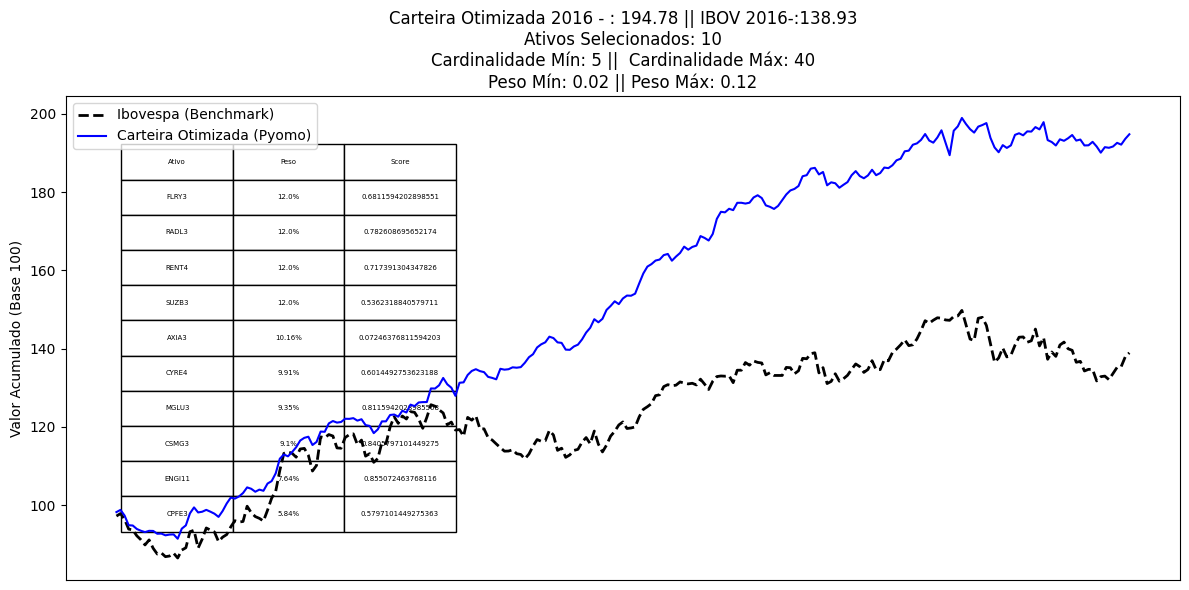

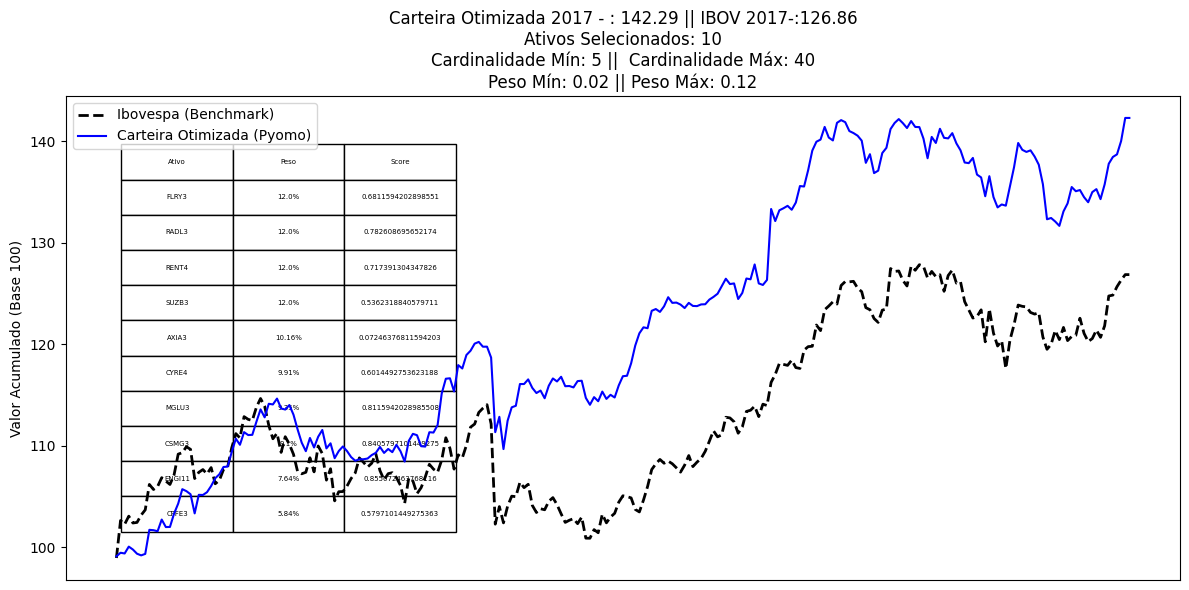

In [ ]:



print(df_final.head(20))
ativos_selecionados = df_final.index
retornos_carteira= df_ativos_2016[ativos_selecionados]
# print(retornos_carteira)
carteira_otimizada = (retornos_carteira*df_final['peso_ativo']).sum(axis=1)
carteira_otimizada = 1 + carteira_otimizada
# print(carteira_otimizada)
# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado = (carteira_otimizada).cumprod() * 100

# acum_equi = (carteira_equi).cumprod() * 100
# acum_otimizado = acum_otimizado[acum_otimizado.index.isin(df_ibov_2016.index)]
acum_ibov = (1 + df_ibov_2016).cumprod() * 100

print(acum_otimizado.tail(1).values[0])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(acum_ibov, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
ax.plot(acum_otimizado, label='Carteira Otimizada (Pyomo)', color='blue')

nome_coluna_tabela = ['Ativo', 'Peso', 'Score']
df_tabela = pd.DataFrame({
    'Ativo': ativos_selecionados,
    'Peso': np.round(df_final.loc[ativos_selecionados, 'peso_ativo'].values*100, 2),
    'Score': [scores_rank.loc[ano_escolhido[0], ativo] for ativo in ativos_selecionados]
})
df_tabela = df_tabela.sort_values(by='Peso', ascending=False)
df_tabela['Peso'] = df_tabela['Peso'].astype(str) + '%'
side_table = ax.table(cellText=df_tabela.values, colLabels=nome_coluna_tabela, cellLoc='center', loc='right', bbox=[0.05, 0.1, 0.3, 0.8], alpha=1)

texto1 = f"Carteira Otimizada 2016 - : {acum_otimizado.tail(1).values[0]:.2f} || IBOV 2016-:{acum_ibov.tail(1).values[0][0]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}\nCardinalidade Mín: {vb_cardinalidade_min} ||  Cardinalidade Máx: {vb_cardinalidade_max}\nPeso Mín: {vb_peso_minimo} || Peso Máx: {vb_peso_maximo}"
ax.set_title(texto1)
ax.set_ylabel('Valor Acumulado (Base 100)')
ax.set_xlabel('Data',labelpad=10)
ax.xaxis.set_visible(False)  # Oculta o eixo x
ax.legend()
ax.grid(False)
plt.tight_layout()


# plotar a carteira escolhida de 2016 para 2017 e comparar com o ibov de 2017

retornos_carteira_2017 = df_ativos_2017[ativos_selecionados]
carteira_otimizada_2017 = (retornos_carteira_2017*df_final['peso_ativo']).sum(axis=1)
carteira_otimizada_2017 = 1 + carteira_otimizada_2017
acum_otimizado_2017 = (carteira_otimizada_2017).cumprod() * 100
acum_otimizado_2017 = acum_otimizado_2017[acum_otimizado_2017.index.isin(df_ibov_2017.index)]

# acum_equi = (carteira_equi).cumprod() * 100
acum_ibov_2017 = (1 + df_ibov_2017).cumprod() * 100

fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(acum_ibov_2017, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
ax1.plot(acum_otimizado_2017, label='Carteira Otimizada (Pyomo)', color='blue')

nome_coluna_tabela = ['Ativo', 'Peso', 'Score']
df_tabela = pd.DataFrame({
    'Ativo': ativos_selecionados,
    'Peso': np.round(df_final.loc[ativos_selecionados, 'peso_ativo'].values*100, 2),
    'Score': [scores_rank.loc[ano_escolhido[0], ativo] for ativo in ativos_selecionados]
})
df_tabela = df_tabela.sort_values(by='Peso', ascending=False)
df_tabela['Peso'] = df_tabela['Peso'].astype(str) + '%'
side_table = ax1.table(cellText=df_tabela.values, colLabels=nome_coluna_tabela, cellLoc='center', loc='right', bbox=[0.05, 0.1, 0.3, 0.8], alpha=1)

texto1 = f"Carteira Otimizada 2017 - : {acum_otimizado_2017.tail(1).values[0]:.2f} || IBOV 2017-:{acum_ibov_2017.tail(1).values[0][0]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}\nCardinalidade Mín: {vb_cardinalidade_min} ||  Cardinalidade Máx: {vb_cardinalidade_max}\nPeso Mín: {vb_peso_minimo} || Peso Máx: {vb_peso_maximo}"
ax1.set_title(texto1)
ax1.set_ylabel('Valor Acumulado (Base 100)')
ax1.set_xlabel('Data',labelpad=10)
ax1.xaxis.set_visible(False)  # Oculta o eixo x
ax1.legend()
ax1.grid(False)
plt.tight_layout()


# # plotar para 2018
# retornos_carteira_2018 = df_ativos_2018[ativos_selecionados]
# carteira_otimizada_2018 = (retornos_carteira_2018*df_final['peso_ativo']).sum(axis=1)
# carteira_otimizada_2018 = 1 + carteira_otimizada_2018
# acum_otimizado_2018 = (carteira_otimizada_2018).cumprod() * 100

# df_ibov_2018_f = df_ibov_2018[df_ibov_2018.index.isin(df_ativos_2018.index)]
# acum_ibov_2018 = (1 + df_ibov_2018['IBOV']).cumprod() * 100
# acum_otimizado_2018 = acum_otimizado_2018[acum_otimizado_2018.index.isin(df_ibov_2018.index)]

# fig2, ax2 = plt.subplots(figsize=(12, 6))
# ax2.plot(acum_ibov_2018, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
# ax2.plot(acum_otimizado_2018, label='Carteira Otimizada (Pyomo)', color='blue')
# df_tabela_2018 = pd.DataFrame({
#     'Ativo': ativos_selecionados,
#     'Peso': np.round(df_final.loc[ativos_selecionados, 'peso_ativo'].values*100, 2),
#     'Score': [scores_rank.loc[ano_escolhido[0], ativo] for ativo in ativos_selecionados]
# })
# df_tabela_2018 = df_tabela_2018.sort_values(by='Peso', ascending=False)
# df_tabela_2018['Peso'] = df_tabela_2018['Peso'].astype(str) + '%'
# side_table = ax2.table(cellText=df_tabela_2018.values, colLabels=nome_coluna_tabela, cellLoc='center', loc='right', bbox=[0.05, 0.1, 0.3, 0.8], alpha=1) 

# texto2 = f"Carteira Otimizada 2018 - : {acum_otimizado_2018.tail(1).values[0]:.2f} || IBOV 2018-:{acum_ibov_2018.tail(1).values[0]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}\nCardinalidade Mín: {vb_cardinalidade_min} ||  Cardinalidade Máx: {vb_cardinalidade_max}\nPeso Mín: {vb_peso_minimo} || Peso Máx: {vb_peso_maximo}"
# ax2.set_title(texto2)
# ax2.set_ylabel('Valor Acumulado (Base 100)')
# ax2.set_xlabel('Data',labelpad=10)
# ax2.xaxis.set_visible(False)  # Oculta o eixo x
# ax2.legend()
# ax2.grid(False)
# plt.tight_layout()



## Comparando a carteira de 2016 com os anos seguintes

Text(0.5, 1.0, 'Comparação Carteira Otimizada vs Ibovespa (2016-2025)')

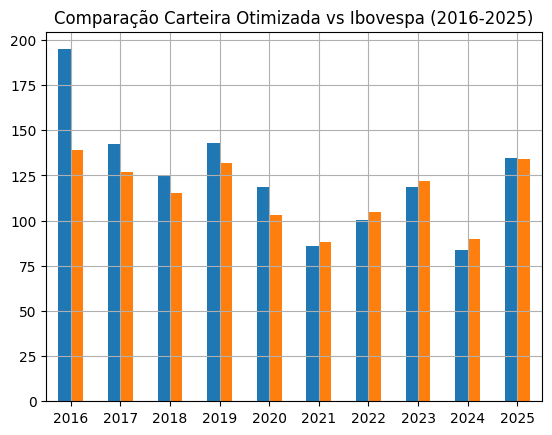

In [ ]:
y = []

for a in anos[:-1]:
    y.append(a.split('-')[0])

# Sharpe da carteira


# df_ativos_2016
# print(df_final)
valores_acumulados = []
valores_acumulados_ibov = []
for an in y:
    df_y = f'df_ativos_{an}'
    retornos = pd.DataFrame(eval(df_y))
    retornos = retornos[ativos_selecionados]
    carteira_otimizada = (retornos*df_final['peso_ativo']).sum(axis=1)
    carteira_otimizada = 1 + carteira_otimizada
    acum_otimizado = (carteira_otimizada).cumprod() * 100
    
    ibov_y = f'df_ibov_{an}'
    df_ibov_y = pd.DataFrame(eval(ibov_y))
    retornos_ibov = 1 + df_ibov_y
    retornos_ibov = retornos_ibov[retornos_ibov.index.isin(carteira_otimizada.index)]
    acum_ibov_y = (retornos_ibov).cumprod() * 100
    


    valores_acumulados.append(acum_otimizado.tail(1).values[0])
    valores_acumulados_ibov.append(acum_ibov_y.tail(1).values[0])

df_valores_ativos = pd.DataFrame(valores_acumulados, index=y, columns=['Valor Acumulado'])
df_valores_ibov = pd.DataFrame(valores_acumulados_ibov, index=y, columns=['Valor Acumulado IBOV'])
df_concate = pd.concat([df_valores_ativos, df_valores_ibov], axis=1).sort_index(ascending=True)

#ordenar pelo index menor
# print(df_concate.sort_index(ascending=True))
# fig, ax = plt.subplots(figsize=(12, 6))
#em modelo de BARRA
# ax.plot(df_concate.sort_index(ascending=True)['Valor Acumulado'], label='Carteira Otimizada (Pyomo)', color='blue', marker='o')
# ax.plot(df_concate.sort_index(ascending=True)['Valor Acumulado IBOV'], label='Ibovespa (Benchmark)', color='black', marker='o', linestyle='--')
# ax.bar(df_concate.sort_index(ascending=True).index, [df_concate.sort_index(ascending=True)['Valor Acumulado'],df_concate.sort_index(ascending=True)['Valor Acumulado IBOV']], alpha=0.5, color='blue', label='Carteira Otimizada (Pyomo)')
# ax.bar(df_concate.sort_index(ascending=True).index, df_concate.sort_index(ascending=True)['Valor Acumulado IBOV'], alpha=0.5, color='black', label='Ibovespa (Benchmark)')  

df_concate.plot(kind="bar", legend=False, rot=0)

plt.grid(True)
plt.title("Comparação Carteira Otimizada vs Ibovespa (2016-2025)")

## Sharpe da Carteira otimiazada 2016

In [ ]:
# 1. série de retorno diário DA CARTEIRA (pesos fixos)
r_p = (df_ativos_2016[ativos_selecionados] * df_final['peso_ativo']).sum(axis=1)

# 2. excesso diário da carteira
exc_p = r_p - selic_d_2016['valor_diario']

# 3. Sharpe diário e anualizado (pro relatório)
sharpe_diario = exc_p.mean() / exc_p.std()
sharpe_anual  = sharpe_diario * np.sqrt(252)
print(f'Sharpe diário: {sharpe_diario:.4f}  |  anualizado: {sharpe_anual:.2f}')

Sharpe diário: 0.2778  |  anualizado: 4.41


## Carteiras criadas na Restrição Cone de Segunda ordem

In [ ]:
carteiras_criadas

[{'ativos_selecionados': {0: 0.0,
   1: 0.0,
   2: 0.06283113851866826,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.0,
   8: 0.0,
   9: 0.0,
   10: 0.0,
   11: 0.0,
   12: 0.0,
   13: 0.0,
   14: 0.0,
   15: 0.0,
   16: 0.0,
   17: 0.0,
   18: 0.0,
   19: 0.11999999658181255,
   20: 0.0,
   21: 0.0,
   22: 0.0,
   23: 0.0,
   24: 0.0,
   25: 0.0,
   26: 0.0,
   27: 0.0,
   28: 0.09071118140367355,
   29: 0.05443612158708434,
   30: 0.119999995450638,
   31: 0.0,
   32: 0.0,
   33: 0.0,
   34: 0.0,
   35: 0.0,
   36: 0.11999993918952455,
   37: 0.0,
   38: 0.0,
   39: 0.0,
   40: 0.0,
   41: 0.11999999997769233,
   42: 0.0,
   43: 0.0,
   44: 0.11999997805896721,
   45: 0.0,
   46: 0.0,
   47: 0.0,
   48: 0.0,
   49: 0.0,
   50: 0.0,
   51: 0.11999996426086117,
   52: 0.0,
   53: 0.0,
   54: 0.0,
   55: 0.0,
   56: 0.0,
   57: 0.0,
   58: 0.0,
   59: 0.0,
   60: 0.07202169244469929,
   61: 0.0,
   62: 0.0,
   63: 0.0,
   64: 0.0,
   65: 0.0,
   66: 0.0,
   67: 0.0,
   68: 0.0},


In [ ]:
lista_carteiras_sharpes = []
for carteira in carteiras_criadas:
    final = pd.DataFrame({
        'peso_ativo': [carteira['ativos_selecionados'][a] for a in model.ativos],
        'ativado': [1 if carteira['ativos_selecionados'][a] > 1e-6 else 0 for a in model.ativos],
    }, index=lista_ativos_finais)
    df_final = final[final['ativado']!=0]
    print(len(df_final))
    # print(df_final)
    lista_carteiras_sharpes.append(df_final)

10
11
11
10


In [ ]:
lista_carteiras_sharpes

[        peso_ativo  ativado
 AXIA3     0.062831        1
 CSMG3     0.120000        1
 ENGI11    0.090711        1
 EQTL3     0.054436        1
 FLRY3     0.120000        1
 ISAE4     0.120000        1
 MGLU3     0.120000        1
 MULT3     0.120000        1
 RADL3     0.120000        1
 TAEE11    0.072022        1,
         peso_ativo  ativado
 AXIA3     0.120000        1
 CPFE3     0.080606        1
 CSMG3     0.120000        1
 ENGI11    0.120000        1
 EQTL3     0.086244        1
 FLRY3     0.120000        1
 ISAE4     0.025544        1
 MGLU3     0.120000        1
 RADL3     0.120000        1
 RENT4     0.052593        1
 TAEE11    0.035014        1,
         peso_ativo  ativado
 AXIA3     0.118288        1
 CPFE3     0.059173        1
 CSMG3     0.110194        1
 ENGI11    0.092960        1
 EQTL3     0.020001        1
 FLRY3     0.120000        1
 MGLU3     0.115039        1
 POMO4     0.020000        1
 RADL3     0.120000        1
 RENT4     0.104345        1
 SUZB3     0

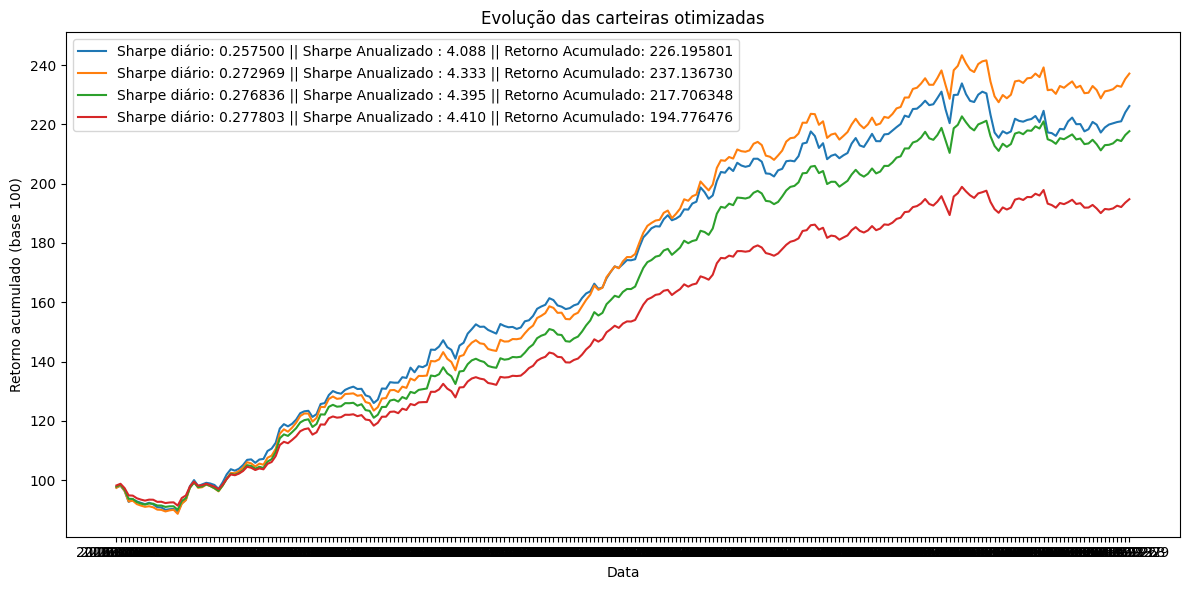

In [ ]:
fig1, ax1 = plt.subplots(figsize=(12, 6))
lista_dados_sharpe = []

for i, carteiraa in enumerate(lista_carteiras_sharpes):
    ativos_selecionados = carteiraa.index
    retornos_carteira = df_ativos_2016[ativos_selecionados]
    carteira_otimizada = 1 + (retornos_carteira * carteiraa['peso_ativo']).sum(axis=1)
    acum_otimizado = carteira_otimizada.cumprod() * 100

    sharpe_c = carteiras_criadas[i]['sharpe']
    ret_final = acum_otimizado.iloc[-1]
    lista_dados_sharpe.append((ret_final, sharpe_c))

    ax1.plot(acum_otimizado.index, acum_otimizado, label=f"Sharpe diário: {sharpe_c:.6f} || Sharpe Anualizado : {sharpe_c*np.sqrt(252):.3f} || Retorno Acumulado: {ret_final:2f}")

ax1.set_xlabel("Data")
ax1.set_ylabel("Retorno acumulado (base 100)")
ax1.set_title("Evolução das carteiras otimizadas")
ax1.legend()
plt.tight_layout()

(0.2575, 0.27296875, 0.2768359375, 0.277802734375)


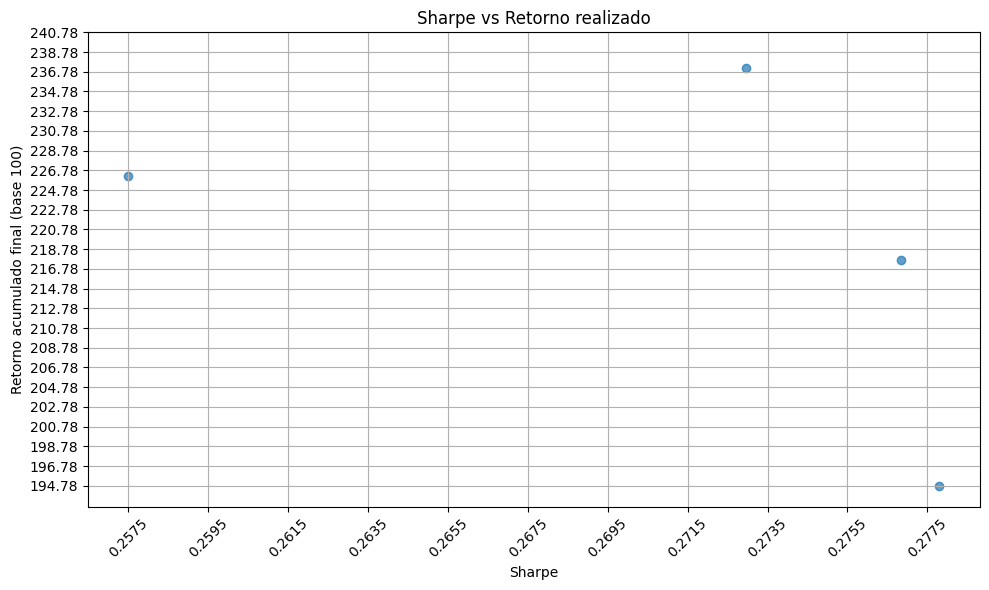

In [ ]:
retornos, sharpes = zip(*lista_dados_sharpe)
print(sharpes)
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.scatter(sharpes, retornos, alpha=0.7)
ax2.set_xlabel("Sharpe")
ax2.set_ylabel("Retorno acumulado final (base 100)")
ax2.set_title("Sharpe vs Retorno realizado")
ax2.set_xticks(np.arange(np.min(sharpes), np.max(sharpes), 0.002))
ax2.set_yticks(np.arange(np.min(retornos), np.max(retornos)+5, 2))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()